In [63]:
! pip install pandas

In [64]:
! pip install matplotlib

In [65]:
! pip install seaborn

In [66]:
! pip install scikit-learn

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings(action='ignore')

In [68]:
df_weather = pd.read_csv('data/weather_v2.csv')
df_target = pd.read_csv('data/target_v2.csv')
df_area = pd.read_csv('data/lookupTable_area.csv')

In [69]:
df_weather.head(30)

,area,datetime,temp,temp_QCFlag,prec,prec_QCFlag,ws,ws_QCFlag,wd,wd_QCFlag,...,vis,sfctype,weathernumber,sfctemp,sfctemp_QCFlag,landtemp_5cm,landtemp_10cm,landtemp_20cm,landtemp_30cm,station
0,184,2018-02-01 01:00,4.7,0.0,NaN,NaN,3.6,0.0,20.0,0.0,...,1950.0,NaN,NaN,2.9,0.0,3.7,3.9,4.2,4.9,ASOS
1,184,2018-02-01 02:00,4.8,0.0,NaN,NaN,2.6,0.0,360.0,0.0,...,1865.0,NaN,NaN,2.9,0.0,3.6,3.8,4.2,4.9,ASOS
2,184,2018-02-01 03:00,4.8,0.0,NaN,NaN,4.6,0.0,20.0,0.0,...,1855.0,NaN,NaN,3.0,0.0,3.6,3.8,4.3,4.9,ASOS
3,184,2018-02-01 04:00,4.5,0.0,NaN,NaN,5.7,0.0,20.0,0.0,...,1425.0,NaN,NaN,3.0,0.0,3.6,3.8,4.2,5.0,ASOS
4,184,2018-02-01 05:00,4.5,0.0,NaN,9.0,4.4,0.0,20.0,0.0,...,1043.0,NaN,1.0,3.0,0.0,3.5,3.8,4.2,4.9,ASOS
5,184,2018-02-01 06:00,4.5,0.0,0.0,0.0,3.8,0.0,20.0,0.0,...,1024.0,NaN,NaN,2.9,0.0,3.5,3.8,4.2,5.0,ASOS
6,184,2018-02-01 07:00,4.7,0.0,NaN,9.0,5.3,0.0,20.0,0.0,...,974.0,NaN,40.0,2.9,0.0,3.5,3.7,4.1,5.0,ASOS
7,184,2018-02-01 08:00,4.5,0.0,NaN,9.0,4.5,0.0,20.0,0.0,...,943.0,NaN,40.0,2.8,0.0,3.5,3.7,4.2,4.9,ASOS
8,184,2018-02-01 09:00,4.4,0.0,NaN,9.0,4.1,0.0,20.0,0.0,...,968.0,NaN,4019.0,3.0,0.0,3.5,3.7,4.1,4.9,ASOS
9,184,2018-02-01 10:00,4.6,0.0,NaN,9.0,4.1,0.0,20.0,0.0,...,981.0,NaN,19.0,3.8,0.0,3.5,3.6,4.2,4.9,ASOS


In [70]:
df_target.head(5).T

,0,1,2,3,4
date,2018-02-01,2018-02-02,2018-02-03,2018-02-04,2018-02-05
smp_max,150.65,163.86,164.07,171.0,170.34
smp_min,116.84,116.84,116.85,115.76,123.89
smp_mean,132.71,134.19,131.39,131.89,137.96
supply,87.47,86.64,88.28,86.14,90.63


In [71]:
df_area.head(5).T

,0,1,2,3,4
area,184,185,188,189,328
name,제주,고산,성산,서귀포,중문


### 가설
- 습도가 높으면 SMP가 높을 것이다.
- 기온이 높으면 SMP가 높을 것이다.
- 지면 온도도 SMP에 영향을 주는가?
- 풍속이 강할 수록 SMP가 높을 것이다.

### 전처리
1. 제주 지역 제외하기 (육지와 제주의 smp가격이 상이하다.)
   <br> -> 그렇다고 smp가격 데이터가 분류된것은 아님, 하지만 smp의 통계에 제주도의 영향은 매우 적음(출처: https://new.kpx.or.kr/smpYearly.es?mid=a10606080400&device=pc)

In [72]:
df_weather = df_weather[df_weather['area'] != 184]

2. Target: date 쪼개기(년,월,일)

In [73]:
df_target['date'] = pd.to_datetime(df_target['date'])

df_target['year'] = df_target['date'].dt.year
df_target['month'] = df_target['date'].dt.month
df_target['day'] = df_target['date'].dt.day

3. weather: 지역 상관없이 같은 시간별 온도, 지면 온도, 습도, 풍속 평균내기

In [74]:
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])

df_avg = df_weather.groupby('datetime').agg({
    'temp': 'mean',
    'humid': 'mean',
    'sfctemp': 'mean',
    'ws': 'mean'
})
df_avg = df_avg.rename(columns={
    'temp': 'temp_avg',
    'humid': 'humid_avg',
    'sfctemp': 'sfctemp_avg',
    'ws': 'ws_avg'
})

df_avg.head(20)

,temp_avg,humid_avg,sfctemp_avg,ws_avg
datetime,,,,
2018-02-01 01:00:00,0.636111,75.865625,2.100000,2.874286
2018-02-01 02:00:00,0.494444,75.484375,1.900000,2.631429
2018-02-01 03:00:00,0.508333,75.259375,1.500000,2.845714
2018-02-01 04:00:00,0.491667,77.381250,1.600000,3.047059
2018-02-01 05:00:00,0.513889,78.331250,1.400000,3.051429
2018-02-01 06:00:00,0.413889,76.975000,1.466667,2.860000
2018-02-01 07:00:00,0.377778,75.968750,1.266667,2.937143
2018-02-01 08:00:00,0.491667,74.375000,1.366667,2.591429
2018-02-01 09:00:00,0.966667,74.315625,2.266667,2.757143


In [75]:
df_weather[df_weather['datetime']=='2018-02-01 05:00'].head(15)

,area,datetime,temp,temp_QCFlag,prec,prec_QCFlag,ws,ws_QCFlag,wd,wd_QCFlag,...,vis,sfctype,weathernumber,sfctemp,sfctemp_QCFlag,landtemp_5cm,landtemp_10cm,landtemp_20cm,landtemp_30cm,station
20114,185,2018-02-01 05:00:00,4.2,0.0,NaN,9.0,6.8,0.0,20.0,0.0,...,808.0,NaN,NaN,2.4,0.0,NaN,NaN,NaN,NaN,ASOS
40218,188,2018-02-01 05:00:00,1.9,0.0,NaN,NaN,1.3,0.0,290.0,0.0,...,961.0,NaN,NaN,0.5,0.0,NaN,NaN,NaN,NaN,ASOS
60328,189,2018-02-01 05:00:00,2.7,0.0,NaN,NaN,1.1,0.0,20.0,0.0,...,2000.0,NaN,NaN,1.3,0.0,NaN,NaN,NaN,NaN,ASOS
80436,328,2018-02-01 05:00:00,2.7,NaN,0.0,NaN,1.7,NaN,356.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
100515,329,2018-02-01 05:00:00,-0.7,NaN,0.0,NaN,0.7,NaN,268.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
120621,330,2018-02-01 05:00:00,2.4,NaN,0.0,NaN,3.3,NaN,2.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
140645,724,2018-02-01 05:00:00,2.7,NaN,0.0,NaN,1.3,NaN,214.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
160659,725,2018-02-01 05:00:00,4.3,NaN,0.0,NaN,3.9,NaN,350.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
180720,726,2018-02-01 05:00:00,4.9,NaN,0.0,NaN,8.7,NaN,11.8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS
200704,727,2018-02-01 05:00:00,-0.7,NaN,0.0,NaN,0.9,NaN,55.8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AWS


### weather와 smp 날짜 기준으로 merge하기

In [76]:
df_target['date'] = pd.to_datetime(df_target['date'])
df_merged = pd.merge(df_avg, df_target[['date', 'smp_mean']], left_on=df_avg.index, right_on='date', how='left')

df_merged.set_index('date', inplace=True)

df_merged.head(30)

,temp_avg,humid_avg,sfctemp_avg,ws_avg,smp_mean
date,,,,,
2018-02-01 01:00:00,0.636111,75.865625,2.100000,2.874286,NaN
2018-02-01 02:00:00,0.494444,75.484375,1.900000,2.631429,NaN
2018-02-01 03:00:00,0.508333,75.259375,1.500000,2.845714,NaN
2018-02-01 04:00:00,0.491667,77.381250,1.600000,3.047059,NaN
2018-02-01 05:00:00,0.513889,78.331250,1.400000,3.051429,NaN
2018-02-01 06:00:00,0.413889,76.975000,1.466667,2.860000,NaN
2018-02-01 07:00:00,0.377778,75.968750,1.266667,2.937143,NaN
2018-02-01 08:00:00,0.491667,74.375000,1.366667,2.591429,NaN
2018-02-01 09:00:00,0.966667,74.315625,2.266667,2.757143,NaN


In [77]:
df_merged.index = df_merged.index.date
df_avg = df_merged.groupby(df_merged.index).mean()

df_avg.index.name = 'date'
df_daily_avg = df_avg.dropna()
df_daily_avg.head(30)

len(df_daily_avg)

836

## 가설 시각화

#### 1. 습도가 높으면 SMP가 높을 것이다.

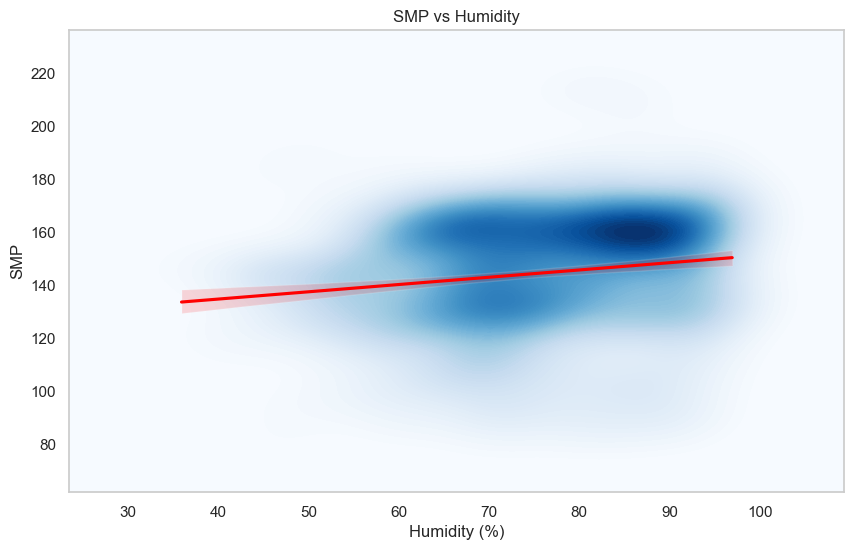

0.27431108854313374


In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# 분포 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_avg, x='humid_avg', y='smp_mean', cmap="Blues", fill=True, thresh=0, levels=100)

# 추세선 그리기
sns.regplot(data=df_avg, x='humid_avg', y='smp_mean', scatter=False, color='red')

plt.xlabel('Humidity (%)')
plt.ylabel('SMP')
plt.title('SMP vs Humidity')

plt.grid(True)
plt.show()

df_clean = df_avg.dropna(subset=['humid_avg', 'smp_mean'])
slope = np.polyfit(df_clean['humid_avg'], df_clean['smp_mean'], 1)[0]
print(slope)


#### 2. 기온이 높으면 SMP가 높을 것이다.

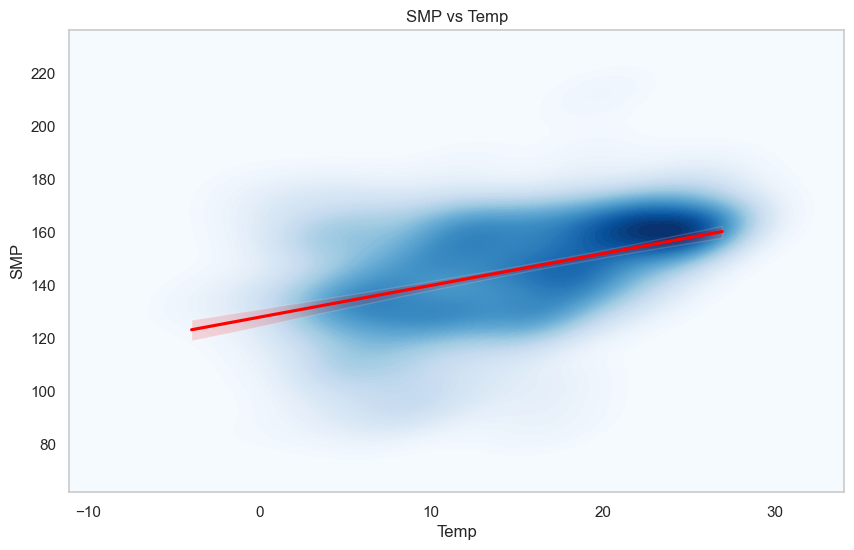

1.198294731777586


In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_avg, x='temp_avg', y='smp_mean', cmap="Blues", fill=True, thresh=0, levels=100)

sns.regplot(data=df_avg, x='temp_avg', y='smp_mean', scatter=False, color='red')

plt.xlabel('Temp')
plt.ylabel('SMP')
plt.title('SMP vs Temp')

plt.grid(True)
plt.show()

import numpy as np
df_clean = df_avg.dropna(subset=['temp_avg', 'smp_mean'])
slope = np.polyfit(df_clean['temp_avg'], df_clean['smp_mean'], 1)[0]

print(slope)


#### 3. 지면 온도가 높으면 SMP가 높을 것이다.

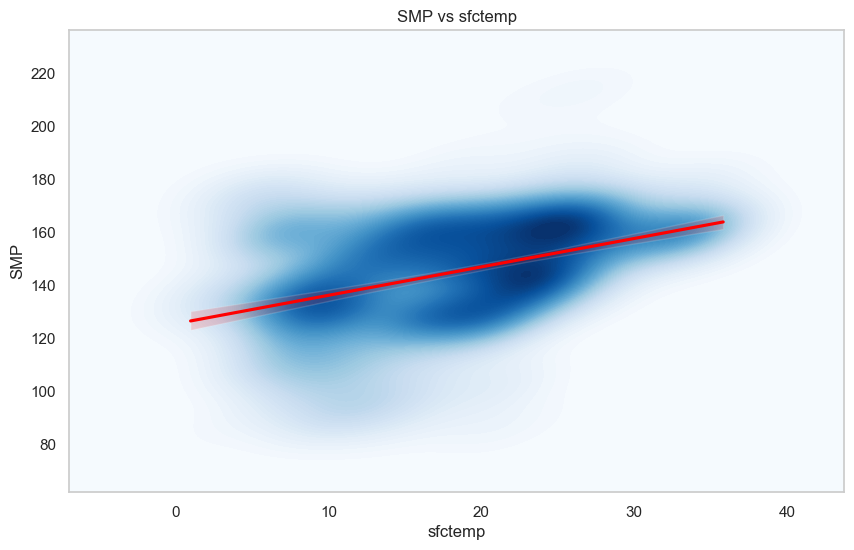

1.0718379364299029


In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_avg, x='sfctemp_avg', y='smp_mean', cmap="Blues", fill=True, thresh=0, levels=100)

sns.regplot(data=df_avg, x='sfctemp_avg', y='smp_mean', scatter=False, color='red')

plt.xlabel('sfctemp')
plt.ylabel('SMP')
plt.title('SMP vs sfctemp')

plt.grid(True)
plt.show()

import numpy as np
df_clean = df_avg.dropna(subset=['sfctemp_avg', 'smp_mean'])
slope = np.polyfit(df_clean['sfctemp_avg'], df_clean['smp_mean'], 1)[0]

print(slope)


#### 4. 풍속이 강할수록 SMP가 높을 것이다.

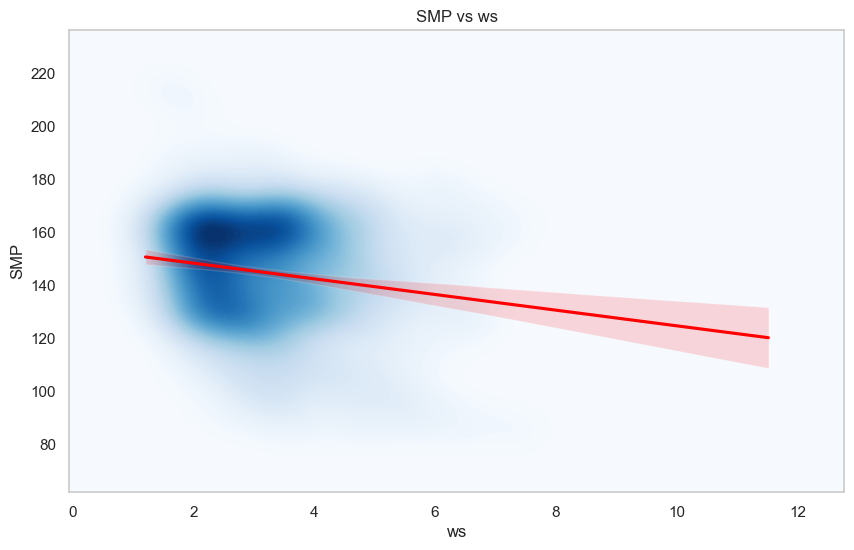

-2.95161789459081


In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_avg, x='ws_avg', y='smp_mean', cmap="Blues", fill=True, thresh=0, levels=100)

sns.regplot(data=df_avg, x='ws_avg', y='smp_mean', scatter=False, color='red')

plt.xlabel('ws')
plt.ylabel('SMP')
plt.title('SMP vs ws')

plt.grid(True)
plt.show()

import numpy as np
df_clean = df_avg.dropna(subset=['ws_avg', 'smp_mean'])
slope = np.polyfit(df_clean['ws_avg'], df_clean['smp_mean'], 1)[0]

print(slope)


### * 가설 정정 -> 풍속이 강할수록 SMP가 낮다.

#### 모델 학습 및 검증
- 앞서 시각화로 검증한 습도, 온도, 지면온도, 풍속과 과거 SMP추세를 가지고 SMP를 예측하는 모델
  - (1) 기상정보 예측
  - (2) (1)를 가지고 SMP 예측

#### 1. 28일 후의 날씨(온도, 지면 온도, 습도, 풍속)예측

In [95]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np
features = ['temp_avg', 'humid_avg', 'sfctemp_avg', 'ws_avg']
target_columns = ['target_temp', 'target_humid', 'target_sfctemp', 'target_ws']

df_avg['target_temp'] = df_avg['temp_avg'].shift(-28)
df_avg['target_humid'] = df_avg['humid_avg'].shift(-28)
df_avg['target_sfctemp'] = df_avg['sfctemp_avg'].shift(-28)
df_avg['target_ws'] = df_avg['ws_avg'].shift(-28)

train_size = int(len(df_avg) * 0.8)
X_train = df_avg[features].iloc[:train_size]
y_train = df_avg[target_columns].iloc[:train_size]
X_test = df_avg[features].iloc[train_size:-28]
y_test = df_avg[target_columns].iloc[train_size:-28]

params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'max_depth': 10,
    'num_leaves': 50,
    'min_data_in_leaf': 20,
    'min_split_gain': 0.01,
    'verbosity': -1 
}

# 각 타겟 컬럼에 대해 별도로 LightGBM 모델 학습
models = {}
for target in target_columns:
    train_data = lgb.Dataset(X_train, label=y_train[target])
    valid_data = lgb.Dataset(X_test, label=y_test[target])
    
    model = lgb.train(params, train_data, valid_sets=[valid_data], 
        num_boost_round=500, callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
    models[target] = model

# RMSE
for target in target_columns:
    y_pred = models[target].predict(X_test)
    mse = mean_squared_error(y_test[target], y_pred)
    rmse = np.sqrt(mse)
    print(f"RMSE for {target}: {rmse}")

# 예측
future_weather = []
current_input = df_avg[features].iloc[-28:].copy()

for day in range(28):
    future_day_prediction = {}
    for target in target_columns:
        prediction = models[target].predict(current_input[features])
        future_day_prediction[target] = prediction[-1]
    
    future_weather.append(future_day_prediction)
    
    new_row = {col: future_day_prediction['target_' + col] for col in ['temp', 'humid', 'sfctemp', 'ws']}
    new_row = pd.DataFrame([new_row])
    current_input = pd.concat([current_input.iloc[1:], new_row], ignore_index=True)

future_weather_df = pd.DataFrame(future_weather, index=pd.date_range(start=df_avg.index[-1] + pd.Timedelta(days=7), periods=28))

print(future_weather_df.head(28))


RMSE for target_temp: 4.0741514543052055
RMSE for target_humid: 12.948593090620951
RMSE for target_sfctemp: 4.174949937772657
RMSE for target_ws: 1.3117188421829697
            target_temp  target_humid  target_sfctemp  target_ws
2020-05-25    17.308843     78.368626       22.868103   3.154067
2020-05-26     7.382920     72.919054       11.207579   3.315058
2020-05-27     7.382920     72.919054       11.207579   3.315058
2020-05-28     7.382920     72.919054       11.207579   3.315058
2020-05-29     7.382920     72.919054       11.207579   3.315058
2020-05-30     7.382920     72.919054       11.207579   3.315058
2020-05-31     7.382920     72.919054       11.207579   3.315058
2020-06-01     7.382920     72.919054       11.207579   3.315058
2020-06-02     7.382920     72.919054       11.207579   3.315058
2020-06-03     7.382920     72.919054       11.207579   3.315058
2020-06-04     7.382920     72.919054       11.207579   3.315058
2020-06-05     7.382920     72.919054       11.207579  

#### 2. 28일 후의 SMP

In [111]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# SMP 생성 가정에 따라 초기 SMP 계산
future_weather_df['SMP'] = (
    future_weather_df['target_temp'] * 1.1982 + 
    future_weather_df['target_humid'] * 0.2743 -
    future_weather_df['target_ws'] * 2.9516 +
    future_weather_df['target_sfctemp'] * 1.0718
)
future_weather_df['previous_SMP'] = future_weather_df['SMP'].shift(1)
future_weather_df.dropna(inplace=True)

features = ['target_temp', 'target_humid', 'target_sfctemp', 'target_ws', 'previous_SMP']
target = 'SMP'

X = future_weather_df[features]
y = future_weather_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'max_depth': 10,
    'num_leaves': 50,
    'learning_rate': 0.01,
    'n_estimators': 1000,
    'verbose': -1 
}

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

model = lgb.train(params, train_data, valid_sets=[valid_data], 
    num_boost_round=1000, callbacks=[lgb.early_stopping(stopping_rounds=10)])

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"SMP 예측에 대한 RMSE: {rmse}")

predicted_smp = model.predict(X)
future_weather_df['Predicted_SMP'] = predicted_smp

print(future_weather_df[['SMP', 'Predicted_SMP']].head(28))

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0
SMP 예측에 대한 RMSE: 8.783957774483042e-07
                  SMP  Predicted_SMP
2020-05-28  31.075469      31.075468
2020-05-29  31.075469      31.075468
2020-05-30  31.075469      31.075468
2020-05-31  31.075469      31.075468
2020-06-01  31.075469      31.075468
2020-06-02  31.075469      31.075468
2020-06-03  31.075469      31.075468
2020-06-04  31.075469      31.075468
2020-06-05  31.075469      31.075468
2020-06-06  31.075469      31.075468
2020-06-07  31.075469      31.075468
2020-06-08  31.075469      31.075468
2020-06-09  31.075469      31.075468
2020-06-10  31.075469      31.075468
2020-06-11  31.075469      31.075468
2020-06-12  31.075469      31.075468
2020-06-13  31.075469      31.075468
2020-06-14  31.075469      31.075468
2020-06-15  31.075469      31.075468
2020-06-16  31.075469      31.075468
2020-06-17  31.075469      31.075468
2020-06-18  31.075469      31.0